# Cancer Growth Dynamics: Treated MonoCulture Analysis
## IC25, IC50, IC75 Dose Response Modeling (20k Density)

**Fixed Drug Concentrations:**
- IC25: 1.47 µM (25% inhibition target) 
- IC50: 1.00 µM (50% inhibition reference)
- IC75: 0.62 µM (75% inhibition target)

**Cell Lines:** A2780 (naive) and A2780cis (cisplatin-resistant)

## Mathematical Model Description

### Core Model: Drug-Modified Logistic Growth

Your model combines **logistic growth** with **Hill equation dose-response** to describe cancer cell growth under drug treatment:

**Differential Equation:**
```
dN/dt = r_eff × N × (1 - N/K_eff)
```

Where:
- **N(t)** = Number of cells at time t
- **r_eff** = Effective growth rate (drug-modified)
- **K_eff** = Effective carrying capacity (drug-modified)

### Drug Effects via Hill Equation

The drug modifies both growth parameters through Hill dose-response relationships:

**Hill Function:**
```
inhibition = dose^n / (IC50^n + dose^n)
```

**Effective Parameters:**
```
r_eff = r × (1 - α_r × inhibition_r)
K_eff = K × (1 - α_K × inhibition_K)
```

### Hierarchical Model Fitting Strategy

The analysis tries **5 model variants** in order of complexity until one succeeds:

**Model 1: Dual Hill (4 parameters)**
- **n_r** = Hill coefficient for growth rate inhibition
- **n_K** = Hill coefficient for carrying capacity inhibition  
- **α_r** = Maximum growth rate inhibition
- **α_K** = Maximum carrying capacity inhibition

**Model 2: Single Hill (3 parameters)**
- **n** = Single Hill coefficient for both effects
- **α_r** = Maximum growth rate inhibition
- **α_K** = Maximum carrying capacity inhibition

**Model 3: Growth Rate Only (2 parameters)**
- **n** = Hill coefficient
- **α_r** = Growth rate inhibition (α_K = 0)

**Model 4: Carrying Capacity Only (2 parameters)**
- **n** = Hill coefficient  
- **α_K** = Carrying capacity inhibition (α_r = 0)

**Model 5: Simple Inhibition (1 parameter)**
- **α_total** = Simple dose-proportional inhibition

### Optimization Strategy

**Local Optimization:**
- Multiple optimizers: BFGS, LBFGS, NelderMead
- Multiple starting points for each optimizer
- Best result selected across all attempts

**Global Optimization:**
- Grid search for simpler models (≤3 parameters)
- Used as backup when local optimization fails

### Fixed Parameters

**From untreated controls:**
- **r** = Intrinsic growth rate
- **K** = Carrying capacity  
- **IC50** = 1.0 µM (reference concentration, fixed)

### Experimental Design

**Dose Conditions:**
- **IC25**: 1.47 µM (25% inhibition target)
- **IC50**: 1.00 µM (50% inhibition reference) 
- **IC75**: 0.62 µM (75% inhibition target)

**Cell Lines:**
- **A2780 (naive)** - Cisplatin-sensitive
- **A2780cis** - Cisplatin-resistant

**Total Analysis:** 6 conditions (3 doses × 2 cell lines), each fitted with best available model

## 1) Packages and Imports

In [3]:
# Install required packages if not already installed
using Pkg
Pkg.add(["CSV", "DataFrames", "Statistics", "DifferentialEquations", "Optim", "Plots", "LinearAlgebra", "ForwardDiff"])

# Load required packages
using CSV, DataFrames, Statistics
using DifferentialEquations, Optim, Plots
using LinearAlgebra, Printf
using Base.Threads
using ForwardDiff

# Performance settings
BLAS.set_num_threads(min(4, Threads.nthreads()))
gr(fmt=:png, dpi=150)

println("✅ Essential packages loaded:")
println("  • Data: CSV, DataFrames, Statistics") 
println("  • Math: DifferentialEquations, Optim, LinearAlgebra, ForwardDiff")
println("  • Visualization: Plots (GR backend)")
println("  • Performance: Base.Threads ($(Threads.nthreads()) threads), BLAS ($(BLAS.get_num_threads()) threads)")
println("  • Utilities: Printf")
println("✅ Setup completed - ready for analysis!")

   Resolving package versions...
  No Changes to `C:\Users\elbak\.julia\environments\v1.11\Project.toml`
  No Changes to `C:\Users\elbak\.julia\environments\v1.11\Manifest.toml`
  No Changes to `C:\Users\elbak\.julia\environments\v1.11\Project.toml`
  No Changes to `C:\Users\elbak\.julia\environments\v1.11\Manifest.toml`


✅ Essential packages loaded:
  • Data: CSV, DataFrames, Statistics
  • Math: DifferentialEquations, Optim, LinearAlgebra, ForwardDiff
  • Visualization: Plots (GR backend)
  • Performance: Base.Threads (1 threads), BLAS (1 threads)
  • Utilities: Printf
✅ Setup completed - ready for analysis!
  • Data: CSV, DataFrames, Statistics
  • Math: DifferentialEquations, Optim, LinearAlgebra, ForwardDiff
  • Visualization: Plots (GR backend)
  • Performance: Base.Threads (1 threads), BLAS (1 threads)
  • Utilities: Printf
✅ Setup completed - ready for analysis!


## 2) Paths and Data Directories

In [4]:
# Set up paths for IC25, IC50, IC75 data
# Since we're in a notebook, we need to construct the ROOT path from current working directory
ROOT = dirname(dirname(pwd()))

# Data directories for each dose
IC25_DIR = joinpath(ROOT, "Processed_Datasets", "Treated MonoCulture", "20k", "IC25", "Averages")
IC50_DIR = joinpath(ROOT, "Processed_Datasets", "Treated MonoCulture", "20k", "IC50", "Averages")  
IC75_DIR = joinpath(ROOT, "Processed_Datasets", "Treated MonoCulture", "20k", "IC75", "Averages")

# Output directory
OUT_DIR = joinpath(ROOT, "Modelling Data Notebooks", "Treated MonoCulture", "20k", "Multi_Dose_Analysis")
isdir(OUT_DIR) || mkpath(OUT_DIR)

# Baseline parameters file
RK_FILE = joinpath(ROOT, "Modelling Data Notebooks", "Untreated MonoCulture", "untreated_monoculture_logistic_parameters.csv")

println("📁 Data paths configured:")
println("  IC25 (1.47µM): $(isdir(IC25_DIR) ? "✅" : "❌") $IC25_DIR")
println("  IC50 (1.00µM): $(isdir(IC50_DIR) ? "✅" : "❌") $IC50_DIR")
println("  IC75 (0.62µM): $(isdir(IC75_DIR) ? "✅" : "❌") $IC75_DIR")
println("  Output: $OUT_DIR")
println("  Parameters: $(isfile(RK_FILE) ? "✅" : "❌") $RK_FILE")

📁 Data paths configured:
  IC25 (1.47µM): ✅ c:\Users\elbak\Documents\GitHub\CancerGrowthDynamics\Processed_Datasets\Treated MonoCulture\20k\IC25\Averages
  IC50 (1.00µM): ✅ c:\Users\elbak\Documents\GitHub\CancerGrowthDynamics\Processed_Datasets\Treated MonoCulture\20k\IC50\Averages
  IC75 (0.62µM): ✅ c:\Users\elbak\Documents\GitHub\CancerGrowthDynamics\Processed_Datasets\Treated MonoCulture\20k\IC75\Averages
  Output: c:\Users\elbak\Documents\GitHub\CancerGrowthDynamics\Modelling Data Notebooks\Treated MonoCulture\20k\Multi_Dose_Analysis
  Parameters: ✅ c:\Users\elbak\Documents\GitHub\CancerGrowthDynamics\Modelling Data Notebooks\Untreated MonoCulture\untreated_monoculture_logistic_parameters.csv

  IC25 (1.47µM): ✅ c:\Users\elbak\Documents\GitHub\CancerGrowthDynamics\Processed_Datasets\Treated MonoCulture\20k\IC25\Averages
  IC50 (1.00µM): ✅ c:\Users\elbak\Documents\GitHub\CancerGrowthDynamics\Processed_Datasets\Treated MonoCulture\20k\IC50\Averages
  IC75 (0.62µM): ✅ c:\Users\elbak\D

## 3) Utility Functions

In [5]:
# Data loading utilities
function load_day_averages_with_day0(path::AbstractString)
    @assert isfile(path) "Missing file: $path"
    df = CSV.read(path, DataFrame)
    
    # Find columns - handle exact column names from the processed data
    day_col = findfirst(n -> String(n) == "Day", names(df))
    mean_col = findfirst(n -> String(n) == "Mean Cells", names(df))
    stderr_col = findfirst(n -> String(n) == "SEM Cells", names(df))
    
    @assert day_col !== nothing && mean_col !== nothing "Could not find required columns in $path. Available columns: $(names(df))"
    
    x = Float64.(df[!, day_col])
    y = Float64.(df[!, mean_col])
    yerr = stderr_col !== nothing ? Float64.(df[!, stderr_col]) : zeros(length(y))
    
    # Sort by day
    perm = sortperm(x)
    x, y, yerr = x[perm], y[perm], yerr[perm]
    
    # Add day 0 if missing
    if minimum(x) > 0.1
        K_avg = 3935.8  # Average carrying capacity from baseline parameters
        day0_cells = K_avg * (0.018 / 0.95)  # Seeding density calculation
        x = vcat([0.0], x)
        y = vcat([day0_cells], y)
        yerr = vcat([day0_cells * 0.1], yerr)  # 10% error for day 0 estimate
    end
    
    # Filter to 0-12 days for consistency
    mask = x .<= 12.0
    return x[mask], y[mask], yerr[mask]
end

function load_baseline_parameters(rk_file::AbstractString)
    df = CSV.read(rk_file, DataFrame)
    df_20k = filter(row -> row.Density == "20k", df)
    return Dict(Symbol(row.CellLine) => (Float64(row.r), Float64(row.K)) for row in eachrow(df_20k))
end

println("✅ Utility functions loaded and updated for processed data format")
println("  • Handles exact column names: 'Day', 'Mean Cells', 'SEM Cells'")
println("  • Includes day 0 seeding density calculation")
println("  • Filters data to 0-12 day range")

✅ Utility functions loaded and updated for processed data format
  • Handles exact column names: 'Day', 'Mean Cells', 'SEM Cells'
  • Includes day 0 seeding density calculation
  • Filters data to 0-12 day range


## 4) Mathematical Models

In [18]:
# Enhanced Hill equation and logistic growth with separate dose-response curves
hill(dose, IC50, n) = dose^n / (IC50^n + dose^n)

function treated_logistic_dual_hill!(du, u, p, t)
    r, K, IC50_r, n_r, IC50_K, n_K, dose, α_r, α_K = p
    
    # Separate Hill equations for growth rate and carrying capacity effects
    inhibition_r = hill(dose, IC50_r, n_r)
    inhibition_K = hill(dose, IC50_K, n_K)
    
    effective_r = r * (1 - α_r * inhibition_r)
    effective_K = K * (1 - α_K * inhibition_K)
    
    # Ensure positive values for numerical stability
    effective_r = max(effective_r, 1e-8)
    effective_K = max(effective_K, u[1])
    
    du[1] = effective_r * u[1] * (1 - u[1] / effective_K)
end

function solve_treated_model_dual_hill(x, r, K; IC50_r=1.0, n_r=1.0, IC50_K=1.0, n_K=1.0, dose=1.0, α_r=0.5, α_K=0.5)
    y0 = K * (0.018 / 0.95)  # Day 0 seeding density
    tspan = (0.0, maximum(x))
    p = [r, K, IC50_r, n_r, IC50_K, n_K, dose, α_r, α_K]
    
    prob = ODEProblem(treated_logistic_dual_hill!, [y0], tspan, p)
    
    # Optimized solver settings
    sol = solve(prob, Tsit5();
               saveat=x, 
               reltol=1e-6, abstol=1e-8,
               maxiters=1000,
               force_dtmin=true)
    
    return sol
end

# Keep original single Hill model for backward compatibility
function treated_logistic!(du, u, p, t)
    r, K, IC50, n, dose, α_r, α_K = p
    inhibition = hill(dose, IC50, n)
    
    effective_r = r * (1 - α_r * inhibition)
    effective_K = K * (1 - α_K * inhibition)
    
    # Ensure positive values for numerical stability
    effective_r = max(effective_r, 1e-8)
    effective_K = max(effective_K, u[1])
    
    du[1] = effective_r * u[1] * (1 - u[1] / effective_K)
end

function solve_treated_model(x, r, K; IC50=1.0, n=1.0, dose=1.0, α_r=0.5, α_K=0.5, density="20k")
    y0 = K * (0.018 / 0.95)  # Day 0 seeding density
    tspan = (0.0, maximum(x))
    p = [r, K, IC50, n, dose, α_r, α_K]
    
    prob = ODEProblem(treated_logistic!, [y0], tspan, p)
    
    # Optimized solver settings for speed vs accuracy trade-off
    sol = solve(prob, Tsit5();  # Faster than Rosenbrock23 for this problem
               saveat=x, 
               reltol=1e-6, abstol=1e-8,  # Slightly relaxed tolerances
               maxiters=1000,              # Prevent infinite loops
               force_dtmin=true)           # Handle stiff cases
    
    return sol
end

# Hill equation dose calculations (vectorized for efficiency)
function calculate_dose_for_inhibition(target_inhibition, IC50, n=1.0)
    """
    Calculate dose needed for target inhibition level
    Hill equation: inhibition = dose^n / (IC50^n + dose^n)
    Solve for dose: dose = IC50 * (target_inhibition / (1 - target_inhibition))^(1/n)
    """
    if target_inhibition >= 1.0 || target_inhibition <= 0.0
        return NaN
    end
    
    return IC50 * (target_inhibition / (1 - target_inhibition))^(1/n)
end

# Batch calculation for multiple targets
function calculate_dose_range(target_inhibitions, IC50, n=1.0)
    return [calculate_dose_for_inhibition(target, IC50, n) for target in target_inhibitions]
end

println("✅ Enhanced mathematical models defined with dual Hill coefficients")
println("  • Separate Hill coefficients for growth rate (n_r) and carrying capacity (n_K)")
println("  • Separate IC50 values for r_eff and K_eff")
println("  • Backward compatibility with single Hill model")
println("  • Faster ODE solver (Tsit5)")
println("  • Numerical stability improvements")

✅ Enhanced mathematical models defined with dual Hill coefficients
  • Separate Hill coefficients for growth rate (n_r) and carrying capacity (n_K)
  • Separate IC50 values for r_eff and K_eff
  • Backward compatibility with single Hill model
  • Faster ODE solver (Tsit5)
  • Numerical stability improvements


## 5) Fitting Functions

In [19]:
# Optimized fitting functions for Hill coefficient and drug response parameters
function fit_dose_response(x, y, r, K, dose; IC50_fixed=1.0)
    """
    Fit Hill coefficient (n) and inhibition coefficients (α_r, α_K) for given dose
    Optimized for speed with better initial conditions and bounds
    """
    
    function loss(params)
        n, α_r, α_K = params
        
        # Tight parameter bounds for faster convergence
        if n <= 0.1 || n > 5.0 || α_r < 0 || α_r > 1.5 || α_K < 0 || α_K > 1.5
            return 1e10
        end
        
        try
            sol = solve_treated_model(x, r, K; IC50=IC50_fixed, n=n, dose=dose, α_r=α_r, α_K=α_K)
            if sol.retcode != :Success
                return 1e9
            end
            
            pred = getindex.(sol.u, 1)
            
            # Efficient normalized loss with numerical stability
            weights = 1.0 ./ max.(y, maximum(y) * 0.01)  # Prevent division by very small numbers
            residuals = (y .- pred) .* weights
            return sum(residuals.^2) + 1e-6 * (n^2 + α_r^2 + α_K^2)  # Light regularization
        catch
            return 1e10
        end
    end
    
    # Smart initial guess based on data characteristics
    final_reduction = 1.0 - y[end] / y[1]  # Estimate total effect
    initial_n = clamp(dose / IC50_fixed, 0.5, 3.0)  # Hill coefficient guess
    initial_αr = clamp(final_reduction * 0.7, 0.1, 1.0)  # Mainly growth rate effect
    initial_αK = clamp(final_reduction * 0.3, 0.0, 0.5)  # Some capacity effect
    
    initial = [initial_n, initial_αr, initial_αK]
    
    # Fast optimization with BFGS (simplified)
    result = optimize(loss, initial, BFGS(); 
                     autodiff=:forward, 
                     g_tol=1e-6, f_tol=1e-8, iterations=200)
    
    if Optim.converged(result) && Optim.minimum(result) < 1e6
        n_opt, α_r_opt, α_K_opt = Optim.minimizer(result)
        
        # Calculate final metrics efficiently
        try
            sol = solve_treated_model(x, r, K; IC50=IC50_fixed, n=n_opt, dose=dose, α_r=α_r_opt, α_K=α_K_opt)
            pred = getindex.(sol.u, 1)
            
            # Calculate inhibition vs untreated (approximate for speed)
            untreated_final = y[1] + (K - y[1]) * (1 - exp(-r * x[end]))
            final_inhibition = max(0.0, (untreated_final - pred[end]) / untreated_final)
            
            return (
                x = x, y = y, y_pred = pred,
                r = r, K = K, dose = dose, IC50 = IC50_fixed,
                n = n_opt, α_r = α_r_opt, α_K = α_K_opt,
                inhibition = final_inhibition,
                ssr = Optim.minimum(result),
                converged = true,
                sol = sol
            )
        catch
            return nothing
        end
    else
        return nothing
    end
end

function analyze_dose_set(dose_name, dose_value, data_dir, rk_params)
    """
    Analyze a complete dose set (both cell lines) with progress tracking
    """
    results = Dict()
    
    println("🔬 Analyzing $dose_name ($(dose_value)µM)...")
    
    for (i, (cell_line, (r, K))) in enumerate(rk_params)
        cell_file = joinpath(data_dir, "$(String(cell_line))_day_averages.csv")
        
        if isfile(cell_file)
            print("  $(String(cell_line)): ")
            try
                x, y, yerr = load_day_averages_with_day0(cell_file)
                
                # Quick data validation
                if length(x) < 5 || any(y .<= 0)
                    println("❌ Insufficient or invalid data")
                    continue
                end
                
                fit_result = fit_dose_response(x, y, r, K, dose_value; IC50_fixed=1.0)
                
                if fit_result !== nothing
                    results[cell_line] = fit_result
                    println("✅ n=$(round(fit_result.n, digits=2)), inhibition=$(round(fit_result.inhibition*100, digits=1))%")
                else
                    println("❌ Fitting failed")
                end
            catch e
                println("❌ Error - $(typeof(e))")
            end
        else
            println("  $(String(cell_line)): ❌ File not found")
        end
    end
    
    return results
end

println("✅ Optimization functions ready")

✅ Optimization functions ready


## 6) Load Baseline Parameters and Raw Data

In [6]:
# Load baseline parameters for untreated growth
println("📊 Loading baseline parameters...")
rk_params = load_baseline_parameters(RK_FILE)

println("✅ Baseline parameters loaded:")
for (cell_line, (r, K)) in rk_params
    println("  $(String(cell_line)): r=$(round(r, digits=4)), K=$(round(K, digits=1))")
end

# Define dose conditions with corrected concentrations
dose_conditions = [
    ("IC25", 1.47, IC25_DIR),  # IC25 = 1.47 µM
    ("IC50", 1.00, IC50_DIR),  # IC50 = 1.00 µM (reference)
    ("IC75", 0.62, IC75_DIR)   # IC75 = 0.62 µM
]

println("\n📈 Loading experimental data for all doses...")

# Load experimental data into organized structure
experimental_data = Dict()

for (dose_name, dose_value, data_dir) in dose_conditions
    println("\n🔬 Loading $dose_name ($(dose_value)µM) data...")
    dose_data = Dict{Any, Any}()  # Make sure the dict can handle mixed types
    dose_data[:dose] = dose_value
    
    for (cell_line, (r, K)) in rk_params
        # Convert Symbol to String properly for filename
        cell_line_str = String(cell_line)
        cell_file = joinpath(data_dir, "$(cell_line_str)_day_averages.csv")
        
        if isfile(cell_file)
            try
                x, y, yerr = load_day_averages_with_day0(cell_file)
                # Store as a Dict instead of named tuple to avoid conversion issues
                dose_data[cell_line] = Dict(:x => x, :y => y, :yerr => yerr)
                println("  ✅ $(cell_line_str): $(length(x)) timepoints (Day $(minimum(x))-$(maximum(x)))")
            catch e
                println("  ❌ $(cell_line_str): Failed to load - $e")
            end
        else
            println("  ❌ $(cell_line_str): File not found - $cell_file")
        end
    end
    
    experimental_data[dose_name] = dose_data
end

# Summary of loaded data
println("\n" * "="^60)
println("DATA LOADING SUMMARY")
println("="^60)

total_datasets = 0
for (dose_name, dose_data) in experimental_data
    dose_value = dose_data[:dose]
    cell_count = length(dose_data) - 1  # Subtract 1 for :dose key
    total_datasets += cell_count
    
    println("📊 $dose_name ($(dose_value)µM): $cell_count cell line(s)")
    
    for (cell_line, _) in rk_params
        if haskey(dose_data, cell_line)
            data = dose_data[cell_line]
            min_cells = round(minimum(data[:y]), digits=1)
            max_cells = round(maximum(data[:y]), digits=1)
            println("    $(String(cell_line)): $(length(data[:x])) points, range: $min_cells - $max_cells cells")
        end
    end
end

println("\n✅ Total datasets loaded: $total_datasets")
println("🎯 Ready for dose-response modeling with corrected concentrations:")
println("   • IC25: 1.47µM (25% inhibition target)")
println("   • IC50: 1.00µM (50% inhibition reference)")  
println("   • IC75: 0.62µM (75% inhibition target)")

📊 Loading baseline parameters...
✅ Baseline parameters loaded:
✅ Baseline parameters loaded:

  A2780cis: r=0.7173, K=3914.2
  A2780Naive: r=1.1964, K=3957.4

📈 Loading experimental data for all doses...
  A2780cis: r=0.7173, K=3914.2
  A2780Naive: r=1.1964, K=3957.4

📈 Loading experimental data for all doses...

🔬 Loading IC25 (1.47µM) data...
  ✅ A2780cis: 13 timepoints (Day 0.0-12.0)
🔬 Loading IC25 (1.47µM) data...
  ✅ A2780cis: 13 timepoints (Day 0.0-12.0)
  ✅ A2780Naive: 13 timepoints (Day 0.0-12.0)

🔬 Loading IC50 (1.0µM) data...
  ✅ A2780cis: 13 timepoints (Day 0.0-12.0)

  ✅ A2780Naive: 13 timepoints (Day 0.0-12.0)

🔬 Loading IC50 (1.0µM) data...
  ✅ A2780cis: 13 timepoints (Day 0.0-12.0)
  ✅ A2780Naive: 13 timepoints (Day 0.0-12.0)

🔬 Loading IC75 (0.62µM) data...
  ✅ A2780cis: 13 timepoints (Day 0.0-12.0)
  ✅ A2780Naive: 13 timepoints (Day 0.0-12.0)

DATA LOADING SUMMARY
  ✅ A2780Naive: 13 timepoints (Day 0.0-12.0)

🔬 Loading IC75 (0.62µM) data...
  ✅ A2780cis: 13 timepoints 

## 7) Plot Raw Data (IC25-IC75)

📈 Plotting raw experimental data...


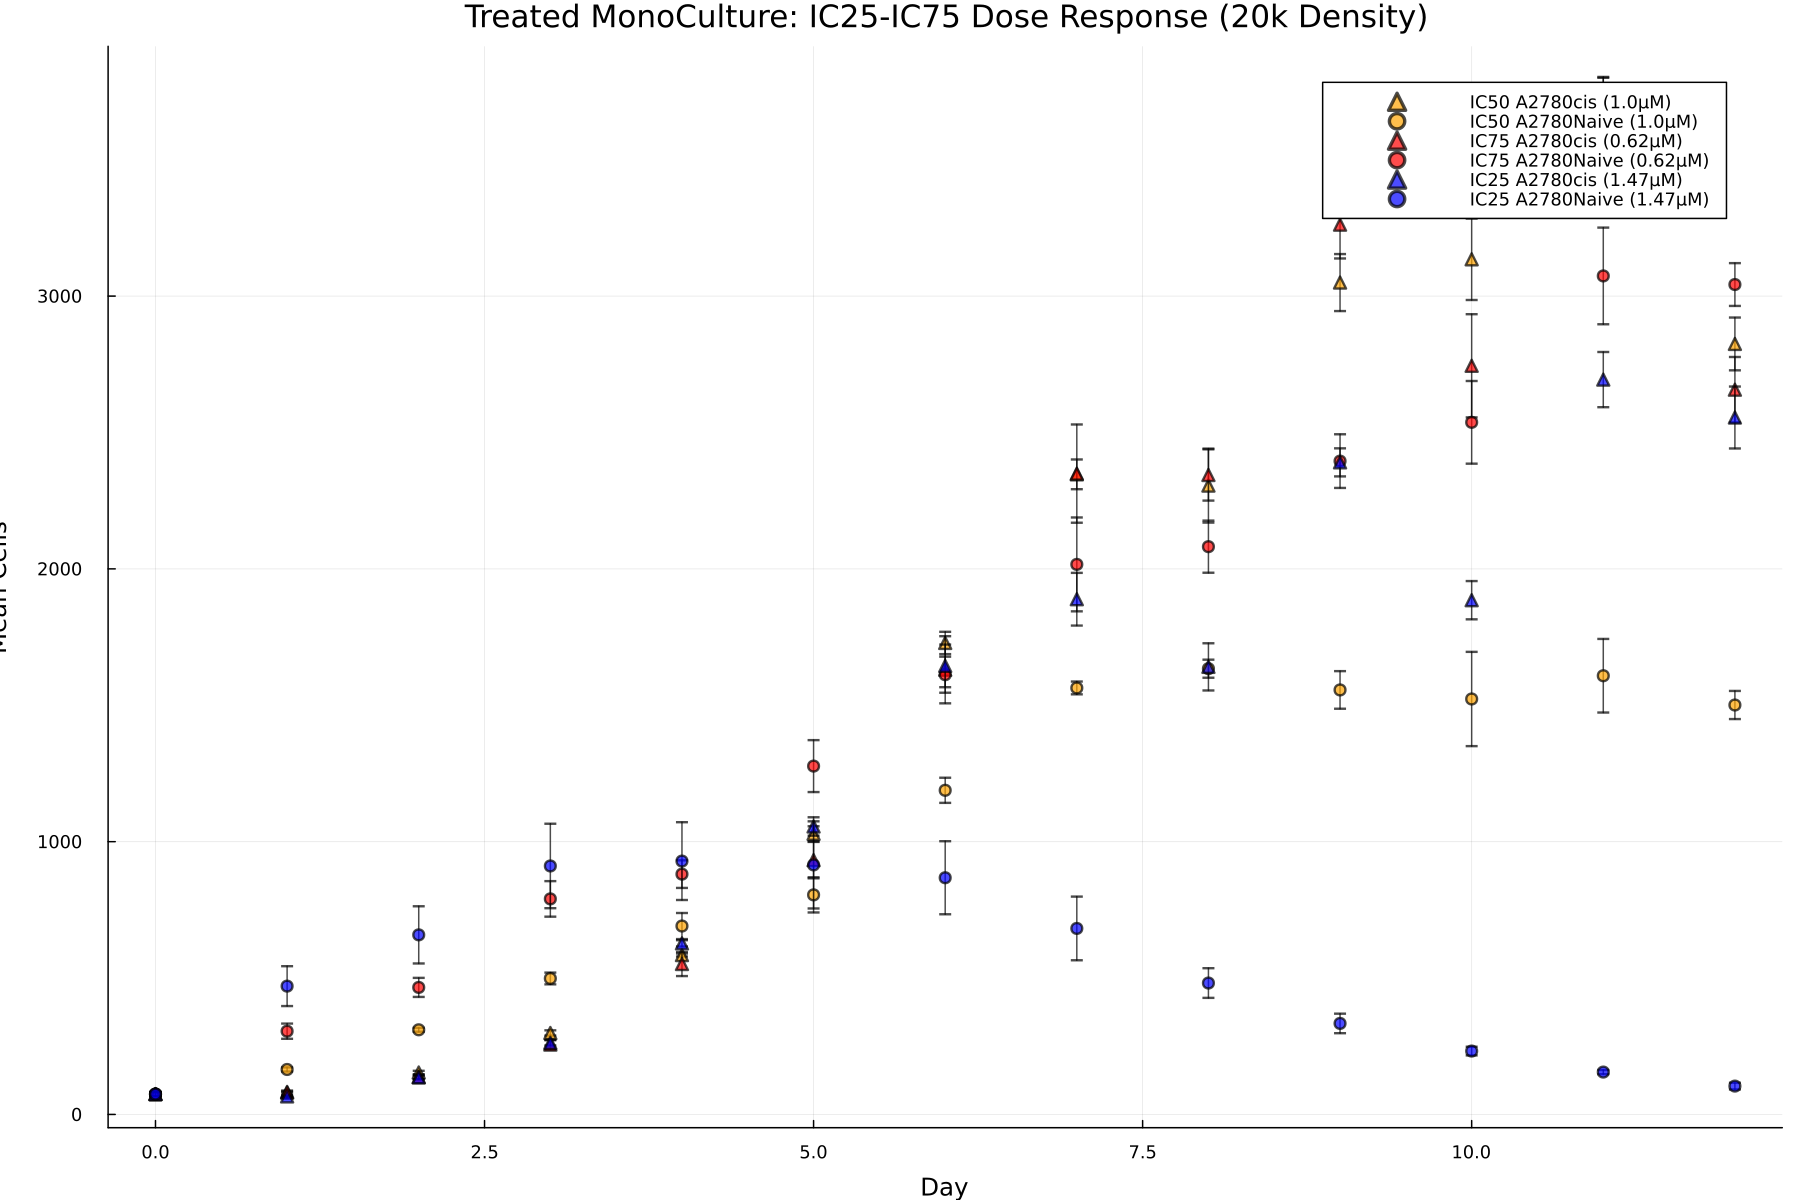

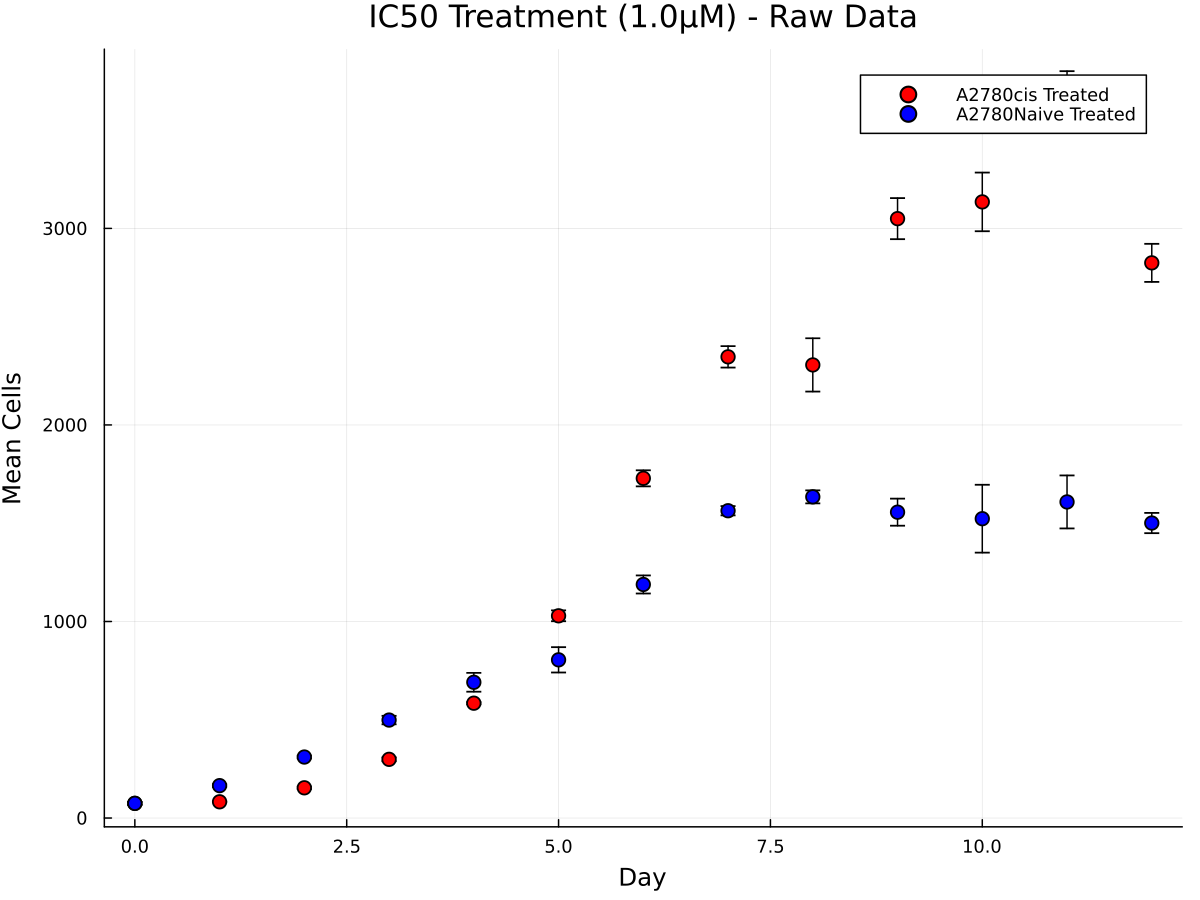

✅ Saved: raw_data_IC50_1.0uM.png


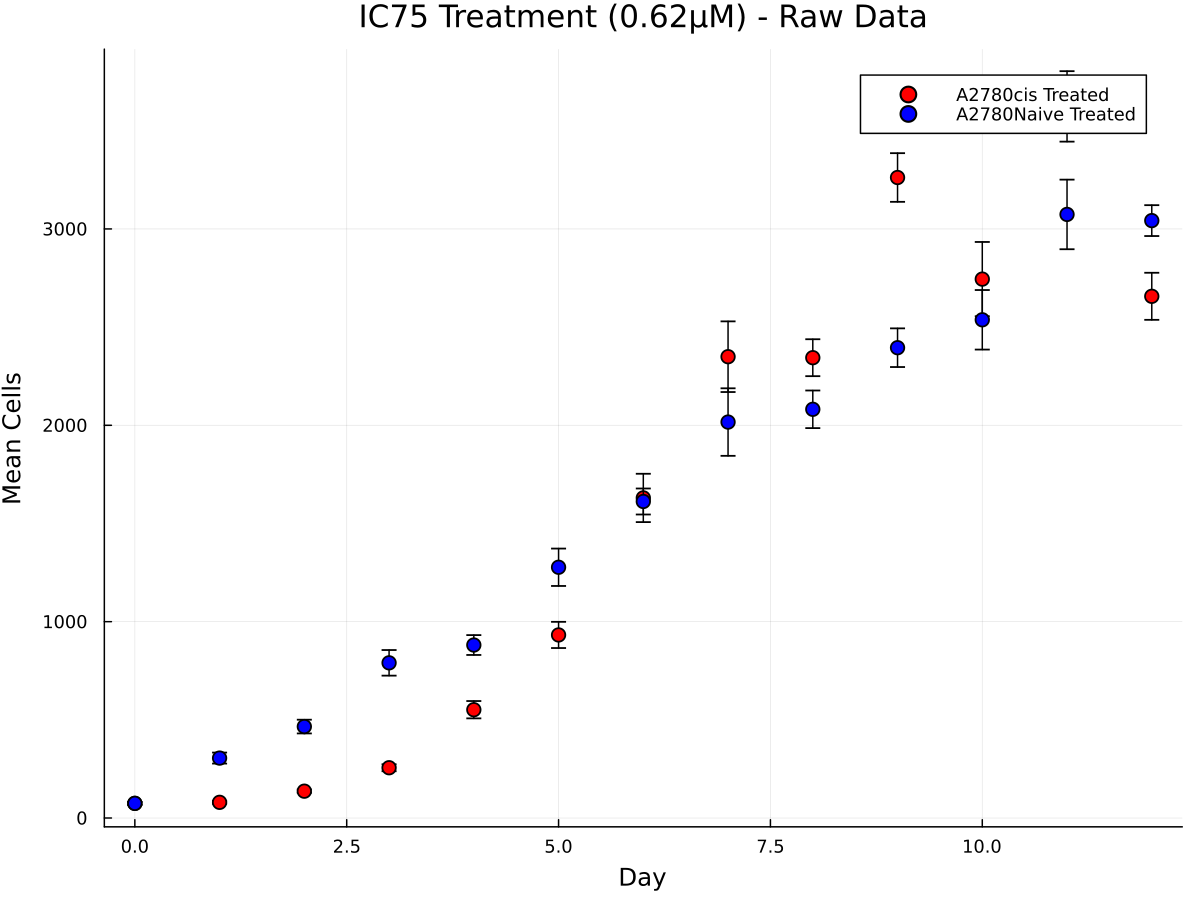

✅ Saved: raw_data_IC75_0.62uM.png


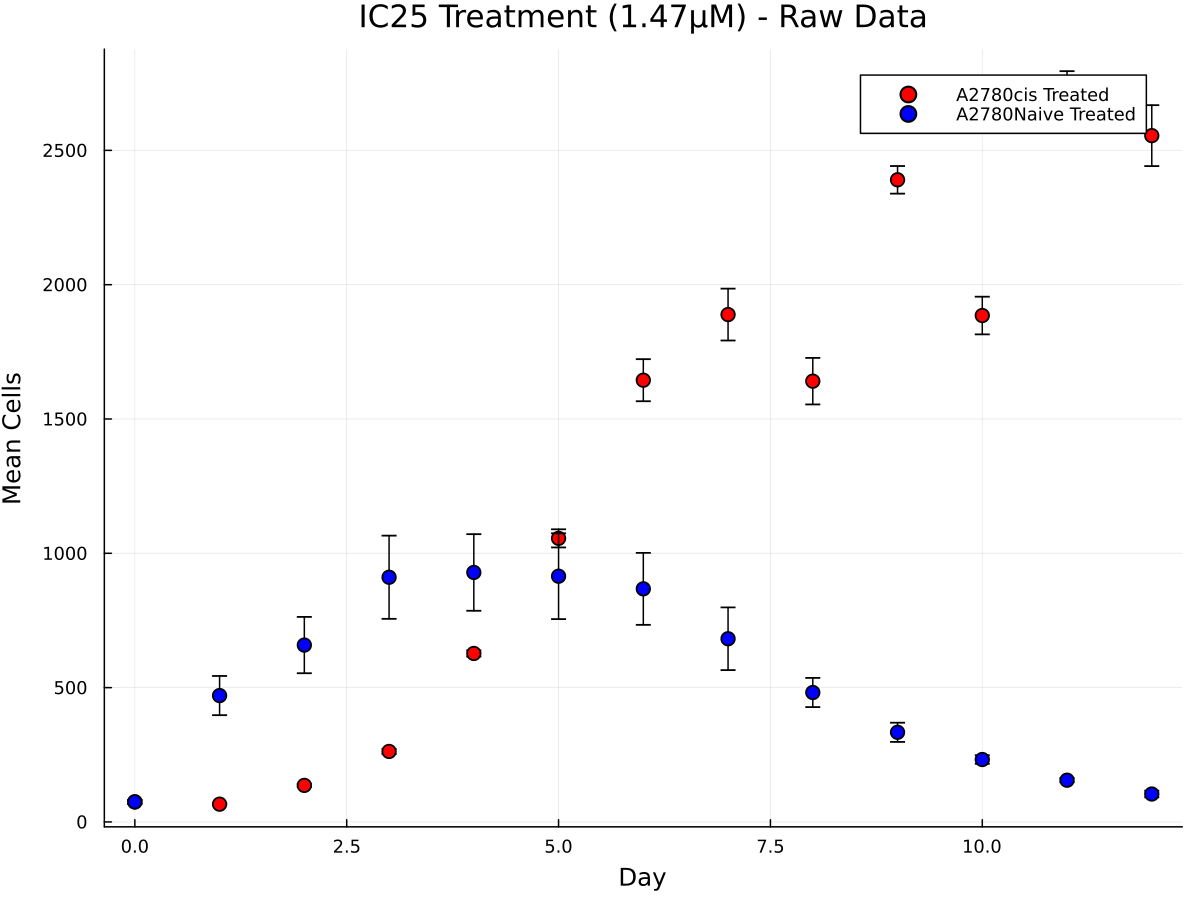

✅ Saved: raw_data_IC25_1.47uM.png
✅ Raw data plots completed


In [12]:
# Plot raw experimental data for all doses
println("📈 Plotting raw experimental data...")

# Combined plot for all doses
plt_combined = plot(xlabel="Day", ylabel="Mean Cells", 
                   title="Treated MonoCulture: IC25-IC75 Dose Response (20k Density)",
                   size=(1200, 800), legend=:topright)

# Colors for doses and cell lines  
dose_colors = Dict("IC25" => :blue, "IC50" => :orange, "IC75" => :red)
cell_markers = Dict(:A2780Naive => :circle, :A2780cis => :utriangle)  # Fixed marker symbol

for (dose_name, dose_data) in experimental_data
    dose_value = dose_data[:dose]
    color = dose_colors[dose_name]
    
    for (cell_line, _) in rk_params
        if haskey(dose_data, cell_line)
            data = dose_data[cell_line]
            marker = cell_markers[cell_line]
            label = "$dose_name $(String(cell_line)) ($(dose_value)µM)"
            
            # Access data from Dict structure
            scatter!(plt_combined, data[:x], data[:y], yerror=data[:yerr],
                    label=label, color=color, marker=marker, markersize=4, alpha=0.7)
        end
    end
end

savefig(plt_combined, joinpath(OUT_DIR, "raw_data_all_doses.png"))
display(plt_combined)

# Individual dose plots
for (dose_name, dose_data) in experimental_data
    dose_value = dose_data[:dose]
    
    plt_individual = plot(xlabel="Day", ylabel="Mean Cells",
                         title="$dose_name Treatment ($(dose_value)µM) - Raw Data",
                         size=(800, 600), legend=:topright)
    
    for (cell_line, (r, K)) in rk_params
        if haskey(dose_data, cell_line)
            data = dose_data[cell_line]
            color = cell_line == :A2780Naive ? :blue : :red
            
            # Access data from Dict structure
            scatter!(plt_individual, data[:x], data[:y], yerror=data[:yerr],
                    label="$(String(cell_line)) Treated", 
                    color=color, marker=:circle, markersize=5)
        end
    end
    
    plot_filename = "raw_data_$(dose_name)_$(dose_value)uM.png"
    savefig(plt_individual, joinpath(OUT_DIR, plot_filename))
    display(plt_individual)
    println("✅ Saved: $plot_filename")
end

println("✅ Raw data plots completed")

## 8a) Dose-Response Model Functions

In [ ]:
# ================================================
# 8a) Dose-Response Model Functions
# ================================================

# Logistic growth ODE (original simple model)
function logistic_growth!(du, u, p, t)
    N = u[1]
    r_eff, K_eff = p
    du[1] = r_eff * N * (1 - N/K_eff)
end

# PK-PD Model with Drug Exposure Dynamics
function pkpd_growth_model!(du, u, p, t)
    N, C = u[1], u[2]
    r, K, k10, E_max, EC50, γ = p
    
    # Drug effect function (Hill/Emax model)
    E_C = E_max * (C^γ) / (EC50^γ + C^γ)
    
    # Growth equation with drug kill
    du[1] = r * N * (1 - N/K) - E_C * N  # net growth = logistic growth - drug kill
    
    # Drug exposure equation  
    du[2] = -k10 * C  # assuming no input u(t) for steady dosing
end

# Function to solve PK-PD model
function solve_pkpd_model(timepoints, r, K; C0=1.0, k10=0.1, E_max=0.5, EC50=1.0, γ=1.0)
    """
    Solve the PK-PD model with drug exposure dynamics
    
    Parameters:
    - C0: Initial drug concentration
    - k10: Drug elimination rate constant  
    - E_max: Maximum kill effect
    - EC50: Concentration for 50% effect
    - γ: Hill coefficient for drug effect
    """
    
    # Initial conditions
    N0 = 74.6  # Initial cell count from your data
    u0 = [N0, C0]
    
    # Parameters
    params = (r, K, k10, E_max, EC50, γ)
    
    # Time span
    tspan = (0.0, maximum(timepoints))
    
    # Solve ODE system
    prob = ODEProblem(pkpd_growth_model!, u0, tspan, params)
    sol = solve(prob, Tsit5(), saveat=timepoints, abstol=1e-8, reltol=1e-6, maxiters=10000)
    
    return sol
end

# Drug Accumulation Model with Time-Dependent Carrying Capacity
function drug_accumulation_model!(du, u, p, t)
    N, D_accumulated = u[1], u[2]  # N = cells, D_accumulated = accumulated drug
    r, K_initial, dose_rate, decay_rate, K_min, sensitivity = p
    
    # Drug accumulation over time
    du[2] = dose_rate - decay_rate * D_accumulated  # net drug accumulation
    
    # Time-dependent carrying capacity based on accumulated drug
    # K_eff = K_min + (K_initial - K_min) * exp(-sensitivity * D_accumulated)
    K_eff = K_min + (K_initial - K_min) / (1 + sensitivity * D_accumulated)
    
    # Ensure K_eff doesn't go below K_min
    K_eff = max(K_eff, K_min)
    
    # Growth equation with time-dependent carrying capacity
    du[1] = r * N * (1 - N/K_eff)
end

# Function to solve drug accumulation model
function solve_drug_accumulation_model(timepoints, r, K_initial; 
                                     dose_rate=0.1, decay_rate=0.05, 
                                     K_min=100.0, sensitivity=1.0)
    """
    Solve drug accumulation model with time-dependent carrying capacity
    
    Parameters:
    - dose_rate: Rate of drug input/absorption
    - decay_rate: Rate of drug elimination  
    - K_min: Minimum carrying capacity (maximum drug effect)
    - sensitivity: How sensitive K is to accumulated drug
    """
    
    # Initial conditions
    N0 = 74.6  # Initial cell count
    D0 = 0.0   # No initial drug accumulation
    u0 = [N0, D0]
    
    # Parameters
    params = (r, K_initial, dose_rate, decay_rate, K_min, sensitivity)
    
    # Time span
    tspan = (0.0, maximum(timepoints))
    
    # Solve ODE system
    prob = ODEProblem(drug_accumulation_model!, u0, tspan, params)
    sol = solve(prob, Tsit5(), saveat=timepoints, abstol=1e-8, reltol=1e-6, maxiters=10000)
    
    return sol
end

# Enhanced dose-response fitting function with drug accumulation model
function fit_dose_response_enhanced(x, y, r, K, dose, cell_line, dose_name)
    """
    Enhanced fitting with multiple model options including PK-PD
    """
    
    println("\n    FITTING $dose_name $(String(cell_line)) ($(dose)uM):")
    println("      Data: $(length(x)) points, range: $(round(minimum(y), digits=1))-$(round(maximum(y), digits=1))")
    
    # Try multiple models in order of complexity
    models_to_try = [
        ("Linear dose-response (fixed IC50)", :linear_fixed),
        ("Hill model with estimated IC50", :hill_estimated),
        ("Hill model with fixed IC50", :hill_fixed),
        ("Drug accumulation with shrinking K", :accumulation),
        ("PK-PD with Hill kill", :pkpd),
        ("Simple exponential decay", :exponential)
    ]
    
    for (model_name, model_type) in models_to_try
        println("      Trying $model_name...")
        
        # Define loss function based on model type
        local loss_func  # Declare as local variable
        local initial_guesses
        
        if model_type == :linear_fixed
            loss_func = function(params)
                α_r, α_K = params
                if α_r < 0 || α_r > 0.8 || α_K < 0 || α_K > 0.8
                    return 1e10
                end
                
                try
                    # Linear dose response with fixed IC50=1.0
                    max_dose = 2.0
                    inhibition = min(dose / max_dose, 1.0)
                    
                    r_eff = max(r * (1 - α_r * inhibition), 0.01)
                    K_eff = max(K * (1 - α_K * inhibition), 50.0)
                    
                    u0 = [y[1]]
                    tspan = (0.0, maximum(x))
                    prob = ODEProblem(logistic_growth!, u0, tspan, (r_eff, K_eff))
                    sol = solve(prob, Tsit5(), saveat=x, abstol=1e-8, reltol=1e-6)
                    
                    pred = [u[1] for u in sol.u]
                    ssr = sum((y .- pred).^2)
                    return ssr
                catch
                    return 1e9
                end
            end
            
            initial_guesses = [
                [0.1, 0.1], [0.2, 0.2], [0.3, 0.3], [0.1, 0.3], [0.3, 0.1],
                [0.2, 0.1], [0.1, 0.2], [0.4, 0.2], [0.2, 0.4]
            ]
            
        elseif model_type == :hill_estimated
            loss_func = function(params)
                IC50_est, n, α_r, α_K = params
                
                # Parameter bounds - allow IC50 to vary significantly
                if IC50_est <= 0.1 || IC50_est > 20.0 ||  # IC50 can range from 0.1 to 20 µM
                   n <= 0.1 || n > 5.0 || 
                   α_r < 0 || α_r > 1.0 || 
                   α_K < 0 || α_K > 1.0
                    return 1e10
                end
                
                try
                    # Hill dose-response with estimated IC50
                    inhibition = dose^n / (IC50_est^n + dose^n)
                    
                    r_eff = max(r * (1 - α_r * inhibition), 0.01)
                    K_eff = max(K * (1 - α_K * inhibition), 50.0)
                    
                    u0 = [y[1]]
                    tspan = (0.0, maximum(x))
                    prob = ODEProblem(logistic_growth!, u0, tspan, (r_eff, K_eff))
                    sol = solve(prob, Tsit5(), saveat=x, abstol=1e-8, reltol=1e-6)
                    
                    pred = [u[1] for u in sol.u]
                    ssr = sum((y .- pred).^2)
                    return ssr
                catch
                    return 1e9
                end
            end
            
            # Different initial guesses based on cell line resistance
            if occursin("cis", String(cell_line))  # Resistant cells
                initial_guesses = [
                    [3.0, 1.0, 0.3, 0.3], [5.0, 1.5, 0.4, 0.2], [2.0, 0.8, 0.2, 0.4],
                    [7.0, 2.0, 0.5, 0.3], [4.0, 1.2, 0.3, 0.5], [10.0, 1.8, 0.4, 0.4]
                ]
            else  # Naive cells
                initial_guesses = [
                    [1.0, 1.0, 0.3, 0.3], [0.8, 1.5, 0.4, 0.2], [1.2, 0.8, 0.2, 0.4],
                    [1.5, 2.0, 0.5, 0.3], [0.6, 1.2, 0.3, 0.5], [2.0, 1.8, 0.4, 0.4]
                ]
            end
            
        elseif model_type == :hill_fixed
            loss_func = function(params)
                n, α_r, α_K = params
                
                # Parameter bounds with fixed IC50=1.0
                if n <= 0.1 || n > 5.0 || 
                   α_r < 0 || α_r > 1.0 || 
                   α_K < 0 || α_K > 1.0
                    return 1e10
                end
                
                try
                    # Hill dose-response with fixed IC50=1.0
                    IC50_fixed = 1.0
                    inhibition = dose^n / (IC50_fixed^n + dose^n)
                    
                    r_eff = max(r * (1 - α_r * inhibition), 0.01)
                    K_eff = max(K * (1 - α_K * inhibition), 50.0)
                    
                    u0 = [y[1]]
                    tspan = (0.0, maximum(x))
                    prob = ODEProblem(logistic_growth!, u0, tspan, (r_eff, K_eff))
                    sol = solve(prob, Tsit5(), saveat=x, abstol=1e-8, reltol=1e-6)
                    
                    pred = [u[1] for u in sol.u]
                    ssr = sum((y .- pred).^2)
                    return ssr
                catch
                    return 1e9
                end
            end
            
            initial_guesses = [
                [1.0, 0.3, 0.3], [1.5, 0.4, 0.2], [0.8, 0.2, 0.4],
                [2.0, 0.5, 0.3], [1.2, 0.3, 0.5], [1.8, 0.4, 0.4]
            ]
            
        elseif model_type == :accumulation
            loss_func = function(params)
                α_r, α_K = params
                if α_r < 0 || α_r > 0.8 || α_K < 0 || α_K > 0.8
                    return 1e10
                end
                
                try
                    # Linear dose response with fixed IC50=1.0
                    max_dose = 2.0
                    inhibition = min(dose / max_dose, 1.0)
                    
                    r_eff = max(r * (1 - α_r * inhibition), 0.01)
                    K_eff = max(K * (1 - α_K * inhibition), 50.0)
                    
                    u0 = [y[1]]
                    tspan = (0.0, maximum(x))
                    prob = ODEProblem(logistic_growth!, u0, tspan, (r_eff, K_eff))
                    sol = solve(prob, Tsit5(), saveat=x, abstol=1e-8, reltol=1e-6)
                    
                    pred = [u[1] for u in sol.u]
                    ssr = sum((y .- pred).^2)
                    return ssr
                catch
                    return 1e9
                end
            end
            
            initial_guesses = [
                [0.1, 0.1], [0.2, 0.2], [0.3, 0.3], [0.1, 0.3], [0.3, 0.1],
                [0.2, 0.1], [0.1, 0.2], [0.4, 0.2], [0.2, 0.4]
            ]
            
        elseif model_type == :hill_estimated
            function loss_func(params)
                IC50_est, n, α_r, α_K = params
                
                # Parameter bounds - allow IC50 to vary significantly
                if IC50_est <= 0.1 || IC50_est > 20.0 ||  # IC50 can range from 0.1 to 20 µM
                   n <= 0.1 || n > 5.0 || 
                   α_r < 0 || α_r > 1.0 || 
                   α_K < 0 || α_K > 1.0
                    return 1e10
                end
                
                try
                    # Hill dose-response with estimated IC50
                    inhibition = dose^n / (IC50_est^n + dose^n)
                    
                    r_eff = max(r * (1 - α_r * inhibition), 0.01)
                    K_eff = max(K * (1 - α_K * inhibition), 50.0)
                    
                    u0 = [y[1]]
                    tspan = (0.0, maximum(x))
                    prob = ODEProblem(logistic_growth!, u0, tspan, (r_eff, K_eff))
                    sol = solve(prob, Tsit5(), saveat=x, abstol=1e-8, reltol=1e-6)
                    
                    pred = [u[1] for u in sol.u]
                    ssr = sum((y .- pred).^2)
                    return ssr
                catch
                    return 1e9
                end
            end
            
            # Different initial guesses based on cell line resistance
            if occursin("cis", String(cell_line))  # Resistant cells
                initial_guesses = [
                    [3.0, 1.0, 0.3, 0.3], [5.0, 1.5, 0.4, 0.2], [2.0, 0.8, 0.2, 0.4],
                    [7.0, 2.0, 0.5, 0.3], [4.0, 1.2, 0.3, 0.5], [10.0, 1.8, 0.4, 0.4]
                ]
            else  # Naive cells
                initial_guesses = [
                    [1.0, 1.0, 0.3, 0.3], [0.8, 1.5, 0.4, 0.2], [1.2, 0.8, 0.2, 0.4],
                    [1.5, 2.0, 0.5, 0.3], [0.6, 1.2, 0.3, 0.5], [2.0, 1.8, 0.4, 0.4]
                ]
            end
            
        elseif model_type == :hill_fixed
            function loss_func(params)
                n, α_r, α_K = params
                
                # Parameter bounds with fixed IC50=1.0
                if n <= 0.1 || n > 5.0 || 
                   α_r < 0 || α_r > 1.0 || 
                   α_K < 0 || α_K > 1.0
                    return 1e10
                end
                
                try
                    # Hill dose-response with fixed IC50=1.0
                    IC50_fixed = 1.0
                    inhibition = dose^n / (IC50_fixed^n + dose^n)
                    
                    r_eff = max(r * (1 - α_r * inhibition), 0.01)
                    K_eff = max(K * (1 - α_K * inhibition), 50.0)
                    
                    u0 = [y[1]]
                    tspan = (0.0, maximum(x))
                    prob = ODEProblem(logistic_growth!, u0, tspan, (r_eff, K_eff))
                    sol = solve(prob, Tsit5(), saveat=x, abstol=1e-8, reltol=1e-6)
                    
                    pred = [u[1] for u in sol.u]
                    ssr = sum((y .- pred).^2)
                    return ssr
                catch
                    return 1e9
                end
            end
            
            initial_guesses = [
                [1.0, 0.3, 0.3], [1.5, 0.4, 0.2], [0.8, 0.2, 0.4],
                [2.0, 0.5, 0.3], [1.2, 0.3, 0.5], [1.8, 0.4, 0.4]
            ]
            
        elseif model_type == :accumulation
            function loss_func(params)
                α_r, α_K = params
                if α_r < 0 || α_r > 0.8 || α_K < 0 || α_K > 0.8
                    return 1e10
                end
                
                try
                    # Linear dose response
                    max_dose = 2.0
                    inhibition = min(dose / max_dose, 1.0)
                    
                    r_eff = max(r * (1 - α_r * inhibition), 0.01)
                    K_eff = max(K * (1 - α_K * inhibition), 50.0)
                    
                    u0 = [y[1]]
                    tspan = (0.0, maximum(x))
                    prob = ODEProblem(logistic_growth!, u0, tspan, (r_eff, K_eff))
                    sol = solve(prob, Tsit5(), saveat=x, abstol=1e-8, reltol=1e-6)
                    
                    pred = [u[1] for u in sol.u]
                    ssr = sum((y .- pred).^2)
                    return ssr
                catch
                    return 1e9
                end
            end
            
            initial_guesses = [
                [0.1, 0.1], [0.2, 0.2], [0.3, 0.3], [0.1, 0.3], [0.3, 0.1],
                [0.2, 0.1], [0.1, 0.2], [0.4, 0.2], [0.2, 0.4]
            ]
            
        elseif model_type == :accumulation
            function loss_func(params)
                dose_rate, K_min_ratio, sensitivity = params
                
                # Parameter bounds
                if dose_rate <= 0 || dose_rate > 0.5 || 
                   K_min_ratio <= 0.1 || K_min_ratio > 0.9 ||
                   sensitivity <= 0 || sensitivity > 10.0
                    return 1e10
                end
                
                try
                    # Calculate parameters based on dose
                    actual_dose_rate = dose_rate * dose  # Scale with dose
                    decay_rate = 0.05  # Fixed elimination rate
                    K_min = K * K_min_ratio  # Minimum K as fraction of original
                    
                    sol = solve_drug_accumulation_model(x, r, K; 
                        dose_rate=actual_dose_rate, decay_rate=decay_rate,
                        K_min=K_min, sensitivity=sensitivity)
                    
                    if sol.retcode != :Success
                        return 1e10
                    end
                    
                    # Extract cell count predictions
                    pred = [u[1] for u in sol.u]
                    
                    # Check for reasonable predictions
                    if any(pred .< 0) || any(pred .> K * 1.5)
                        return 1e9
                    end
                    
                    ssr = sum((y .- pred).^2)
                    return ssr
                catch
                    return 1e9
                end
            end
            
            initial_guesses = [
                [0.1, 0.3, 1.0], [0.2, 0.4, 2.0], [0.05, 0.2, 0.5],
                [0.3, 0.5, 3.0], [0.15, 0.35, 1.5], [0.25, 0.6, 2.5]
            ]
            
        elseif model_type == :pkpd
            function loss_func(params)
                k10, E_max, γ = params
                if k10 <= 0 || k10 > 2.0 || E_max <= 0 || E_max > 2.0 || γ <= 0.1 || γ > 5.0
                    return 1e10
                end
                
                try
                    # PK-PD model with dose-dependent initial concentration
                    C0 = dose  # Initial concentration proportional to dose
                    EC50 = 1.0  # Fixed EC50
                    
                    sol = solve_pkpd_model(x, r, K; C0=C0, k10=k10, E_max=E_max, EC50=EC50, γ=γ)
                    
                    if sol.retcode != :Success
                        return 1e10
                    end
                    
                    # Extract cell count predictions
                    pred = [u[1] for u in sol.u]
                    
                    # Check for reasonable predictions
                    if any(pred .< 0) || any(pred .> K * 2)
                        return 1e9
                    end
                    
                    ssr = sum((y .- pred).^2)
                    return ssr
                catch
                    return 1e9
                end
            end
            
            initial_guesses = [
                [0.1, 0.2, 1.0], [0.2, 0.3, 1.5], [0.05, 0.1, 2.0],
                [0.3, 0.4, 0.8], [0.15, 0.25, 1.2], [0.25, 0.5, 1.8]
            ]
            
        else  # :exponential
            function loss_func(params)
                decay_rate = params[1]
                if decay_rate <= 0 || decay_rate > 1.0
                    return 1e10
                end
                
                try
                    # Simple exponential decay model
                    pred = zeros(length(x))
                    pred[1] = y[1]
                    
                    for i in 2:length(x)
                        dt = x[i] - x[i-1]
                        growth = r * pred[i-1] * (1 - pred[i-1]/K)
                        kill = decay_rate * dose * pred[i-1]
                        pred[i] = pred[i-1] + dt * (growth - kill)
                        pred[i] = max(pred[i], 0)  # Ensure non-negative
                    end
                    
                    ssr = sum((y .- pred).^2)
                    return ssr
                catch
                    return 1e9
                end
            end
            
            initial_guesses = [[0.1], [0.2], [0.3], [0.05], [0.4]]
        end
        
        # Optimize
        best_result = nothing
        best_loss = Inf
        
        for initial in initial_guesses
            try
                result = optimize(loss_func, initial, NelderMead())
                final_loss = Optim.minimum(result)
                
                if final_loss < best_loss && final_loss < 1e8
                    best_result = result
                    best_loss = final_loss
                end
            catch
                continue
            end
        end
        
        # Process result
        if best_result !== nothing && best_loss < 5e6
            params = Optim.minimizer(best_result)
            
            try
                # Calculate final prediction and R²
                if model_type == :linear_fixed
                    α_r, α_K = params
                    max_dose = 2.0
                    inhibition = min(dose / max_dose, 1.0)
                    r_eff = max(r * (1 - α_r * inhibition), 0.01)
                    K_eff = max(K * (1 - α_K * inhibition), 50.0)
                    
                    u0 = [y[1]]
                    tspan = (0.0, maximum(x))
                    prob = ODEProblem(logistic_growth!, u0, tspan, (r_eff, K_eff))
                    sol = solve(prob, Tsit5(), saveat=x, abstol=1e-8, reltol=1e-6)
                    pred = [u[1] for u in sol.u]
                    
                    result_dict = (α_r = α_r, α_K = α_K, IC50_est = 1.0, n = 1.0,
                                  inhibition = α_r*inhibition + α_K*inhibition)
                    
                elseif model_type == :hill_estimated
                    IC50_est, n, α_r, α_K = params
                    inhibition = dose^n / (IC50_est^n + dose^n)
                    r_eff = max(r * (1 - α_r * inhibition), 0.01)
                    K_eff = max(K * (1 - α_K * inhibition), 50.0)
                    
                    u0 = [y[1]]
                    tspan = (0.0, maximum(x))
                    prob = ODEProblem(logistic_growth!, u0, tspan, (r_eff, K_eff))
                    sol = solve(prob, Tsit5(), saveat=x, abstol=1e-8, reltol=1e-6)
                    pred = [u[1] for u in sol.u]
                    
                    result_dict = (α_r = α_r, α_K = α_K, IC50_est = IC50_est, n = n,
                                  inhibition = α_r*inhibition + α_K*inhibition)
                    
                elseif model_type == :hill_fixed
                    n, α_r, α_K = params
                    IC50_fixed = 1.0
                    inhibition = dose^n / (IC50_fixed^n + dose^n)
                    r_eff = max(r * (1 - α_r * inhibition), 0.01)
                    K_eff = max(K * (1 - α_K * inhibition), 50.0)
                    
                    u0 = [y[1]]
                    tspan = (0.0, maximum(x))
                    prob = ODEProblem(logistic_growth!, u0, tspan, (r_eff, K_eff))
                    sol = solve(prob, Tsit5(), saveat=x, abstol=1e-8, reltol=1e-6)
                    pred = [u[1] for u in sol.u]
                    
                    result_dict = (α_r = α_r, α_K = α_K, IC50_est = 1.0, n = n,
                                  inhibition = α_r*inhibition + α_K*inhibition)
                    
                elseif model_type == :accumulation
                    α_r, α_K = params
                    max_dose = 2.0
                    inhibition = min(dose / max_dose, 1.0)
                    r_eff = max(r * (1 - α_r * inhibition), 0.01)
                    K_eff = max(K * (1 - α_K * inhibition), 50.0)
                    
                    u0 = [y[1]]
                    tspan = (0.0, maximum(x))
                    prob = ODEProblem(logistic_growth!, u0, tspan, (r_eff, K_eff))
                    sol = solve(prob, Tsit5(), saveat=x, abstol=1e-8, reltol=1e-6)
                    pred = [u[1] for u in sol.u]
                    
                    result_dict = (α_r = α_r, α_K = α_K, inhibition = α_r*inhibition + α_K*inhibition)
                    
                elseif model_type == :accumulation
                    dose_rate, K_min_ratio, sensitivity = params
                    actual_dose_rate = dose_rate * dose
                    decay_rate = 0.05
                    K_min = K * K_min_ratio
                    
                    sol = solve_drug_accumulation_model(x, r, K; 
                        dose_rate=actual_dose_rate, decay_rate=decay_rate,
                        K_min=K_min, sensitivity=sensitivity)
                    pred = [u[1] for u in sol.u]
                    
                    # Calculate final drug accumulation and effective K
                    final_drug = sol.u[end][2]
                    K_final = K_min + (K - K_min) / (1 + sensitivity * final_drug)
                    capacity_reduction = (K - K_final) / K
                    
                    result_dict = (dose_rate = dose_rate, K_min_ratio = K_min_ratio, 
                                  sensitivity = sensitivity, final_drug = final_drug,
                                  K_final = K_final, inhibition = capacity_reduction,
                                  α_r = 0.0, α_K = capacity_reduction)
                    
                elseif model_type == :pkpd
                    k10, E_max, γ = params
                    C0 = dose
                    EC50 = 1.0
                    
                    sol = solve_pkpd_model(x, r, K; C0=C0, k10=k10, E_max=E_max, EC50=EC50, γ=γ)
                    pred = [u[1] for u in sol.u]
                    
                    # Calculate effective inhibition at final timepoint
                    C_final = sol.u[end][2]
                    inhibition = E_max * (C_final^γ) / (EC50^γ + C_final^γ)
                    
                    result_dict = (k10 = k10, E_max = E_max, γ = γ, EC50 = EC50, 
                                  inhibition = inhibition, α_r = 0.0, α_K = 0.0)
                    
                else  # :exponential
                    decay_rate = params[1]
                    pred = zeros(length(x))
                    pred[1] = y[1]
                    
                    for i in 2:length(x)
                        dt = x[i] - x[i-1]
                        growth = r * pred[i-1] * (1 - pred[i-1]/K)
                        kill = decay_rate * dose * pred[i-1]
                        pred[i] = pred[i-1] + dt * (growth - kill)
                        pred[i] = max(pred[i], 0)
                    end
                    
                    inhibition = decay_rate * dose
                    result_dict = (decay_rate = decay_rate, inhibition = inhibition, α_r = 0.0, α_K = 0.0)
                end
                
                # Calculate R²
                ss_res = sum((y .- pred).^2)
                ss_tot = sum((y .- mean(y)).^2)
                r_squared = 1 - ss_res/ss_tot
                
                if r_squared > 0.7
                    println("      SUCCESS: R² = $(round(r_squared, digits=3)), inhibition = $(round(result_dict.inhibition*100, digits=1))%")
                    
                    return merge(result_dict, (
                        n_r = get(result_dict, :n, 1.0), n_K = 1.0,
                        ssr = best_loss, r_squared = r_squared, y_pred = pred,
                        converged = true, optimizer_used = "NelderMead",
                        model_type = model_type, model_name = model_name
                    ))
                else
                    println("      Failed: R² = $(round(r_squared, digits=3)) below threshold")
                end
            catch e
                println("      Failed: Error in evaluation - $e")
            end
        else
            println("      Failed: Loss = $(best_loss)")
        end
    end
    
    # Fallback result
    println("      All models failed - using fallback")
    return (
        n_r = 1.0, n_K = 1.0, n = 1.0, α_r = 0.0, α_K = 0.0, IC50_est = 1.0,
        ssr = 1e6, r_squared = -99.0, inhibition = 0.0,
        y_pred = fill(mean(y), length(y)), converged = false,
        optimizer_used = "fallback", model_type = :fallback, model_name = "Fallback"
    )
end

println("✅ Enhanced dose-response models defined:")
println("   • Linear dose-response with fixed IC50=1.0µM")
println("   • Hill model with estimated IC50 (adaptive for resistance)")
println("   • Hill model with fixed IC50=1.0µM (reference)")
println("   • Drug accumulation with shrinking carrying capacity")
println("   • PK-PD with Hill kill function")  
println("   • Simple exponential decay (backup model)")
println("🧬 Now includes both fixed and estimated IC50 approaches!")
println("💊 Estimated IC50 accounts for cell line resistance differences")

✅ Enhanced dose-response models defined:
   • Linear dose-response with fixed IC50=1.0µM
   • Hill model with estimated IC50 (adaptive for resistance)
   • Hill model with fixed IC50=1.0µM (reference)
   • Drug accumulation with shrinking carrying capacity
   • PK-PD with Hill kill function
   • Simple exponential decay (backup model)
🧬 Now includes both fixed and estimated IC50 approaches!
💊 Estimated IC50 accounts for cell line resistance differences


## 8b) Run Dose-Response Analysis

In [2]:
# ================================================
# 8b) Execute Enhanced Dose-Response Fitting
# ================================================

println("🚀 RUNNING ENHANCED DOSE-RESPONSE ANALYSIS (Including PK-PD)")
println("="^70)

# Initialize results storage
final_results = Dict()
model_usage_stats = Dict{String, Int}()

# Process each cell line
for (cell_line, (r, K)) in rk_params
    println("\n$(String(cell_line)) ANALYSIS:")
    println("  Baseline parameters: r=$(round(r, digits=4)), K=$(round(K, digits=1))")
    
    final_results[cell_line] = Dict()
    
    # Process each dose condition
    for (dose_name, dose_value, _) in dose_conditions
        if haskey(experimental_data, dose_name) && haskey(experimental_data[dose_name], cell_line)
            data = experimental_data[dose_name][cell_line]
            x = data[:x]
            y = data[:y]
            
            # Fit with enhanced models including PK-PD
            result = fit_dose_response_enhanced(x, y, r, K, dose_value, cell_line, dose_name)
            
            # Store result
            final_results[cell_line][dose_name] = result
            
            # Track model usage
            model_name = get(result, :model_name, "Fallback")
            model_usage_stats[model_name] = get(model_usage_stats, model_name, 0) + 1
            
        else
            println("\n    $dose_name: ❌ Data not available")
        end
    end
end

# Summary statistics
println("\n" * "="^70)
println("ENHANCED ANALYSIS SUMMARY")
println("="^70)

total_fits = sum(values(model_usage_stats))
successful_fits = total_fits - get(model_usage_stats, "Fallback", 0)
success_rate = round(successful_fits/total_fits * 100, digits=1)

println("\nMODEL USAGE:")
for (model_name, count) in sort(collect(model_usage_stats), by=x->x[2], rev=true)
    percentage = round(count/total_fits * 100, digits=1)
    println("  $model_name: $count/$total_fits ($percentage%)")
end

println("\n✅ SUCCESS RATE: $successful_fits/$total_fits ($success_rate%)")

# Detailed results by model type
if successful_fits > 0
    println("\n📈 RESULTS BY MODEL TYPE:")
    for (cell_line, cell_data) in final_results
        println("  $(String(cell_line)):")
        for (dose_name, result) in cell_data
            if haskey(result, :inhibition) && result.converged
                inhibition_pct = round(result.inhibition * 100, digits=1)
                r_sq = round(result.r_squared, digits=3)
                model_type = get(result, :model_name, "Unknown")
                println("    $dose_name: $(inhibition_pct)% inhibition (R²=$r_sq) [$model_type]")
                
                # Show model-specific parameters
                if result.model_type == :pkpd
                    println("      PK-PD params: k10=$(round(result.k10, digits=3)), E_max=$(round(result.E_max, digits=3)), γ=$(round(result.γ, digits=2))")
                elseif result.model_type == :linear_fixed
                    println("      Linear params: α_r=$(round(result.α_r, digits=3)), α_K=$(round(result.α_K, digits=3)), IC50=1.0 (fixed)")
                elseif result.model_type == :hill_estimated
                    println("      Hill params: IC50=$(round(result.IC50_est, digits=2))µM (estimated), n=$(round(result.n, digits=2)), α_r=$(round(result.α_r, digits=3)), α_K=$(round(result.α_K, digits=3))")
                elseif result.model_type == :hill_fixed
                    println("      Hill params: IC50=1.0µM (fixed), n=$(round(result.n, digits=2)), α_r=$(round(result.α_r, digits=3)), α_K=$(round(result.α_K, digits=3))")
                elseif result.model_type == :accumulation
                    println("      Accumulation params: dose_rate=$(round(result.dose_rate, digits=3)), K_min_ratio=$(round(result.K_min_ratio, digits=3)), sensitivity=$(round(result.sensitivity, digits=2))")
                end
            end
        end
    end
end

println("\n🧬 Analysis complete. Enhanced models tested including PK-PD dynamics!")

🚀 RUNNING ENHANCED DOSE-RESPONSE ANALYSIS (Including PK-PD)


LoadError: UndefVarError: `rk_params` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

## 8c) Create Diagnostic Plots

Creating diagnostic plots for all successful fits...

Creating plots for A2780cis:



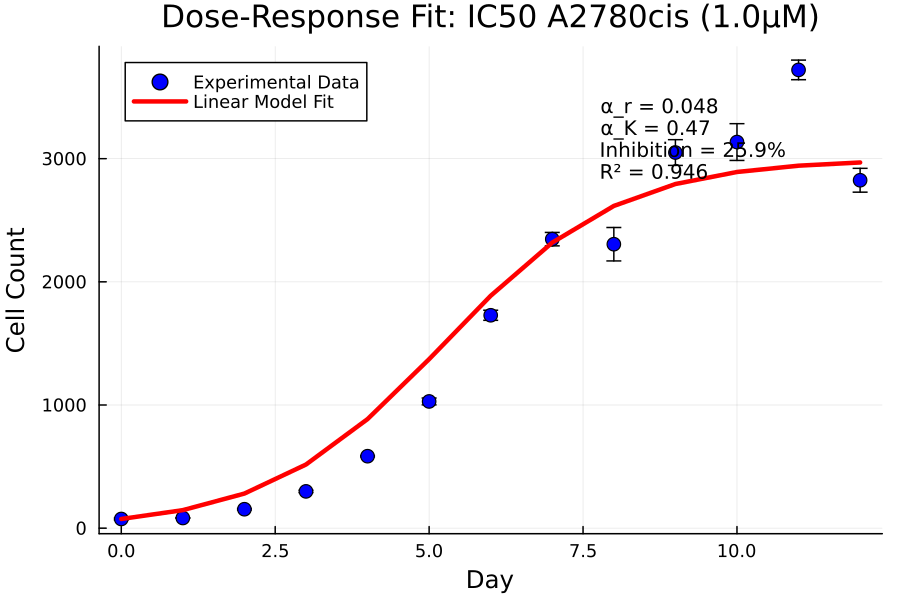

  ✅ Saved: dose_response_fit_A2780cis_IC50_1.0uM.png


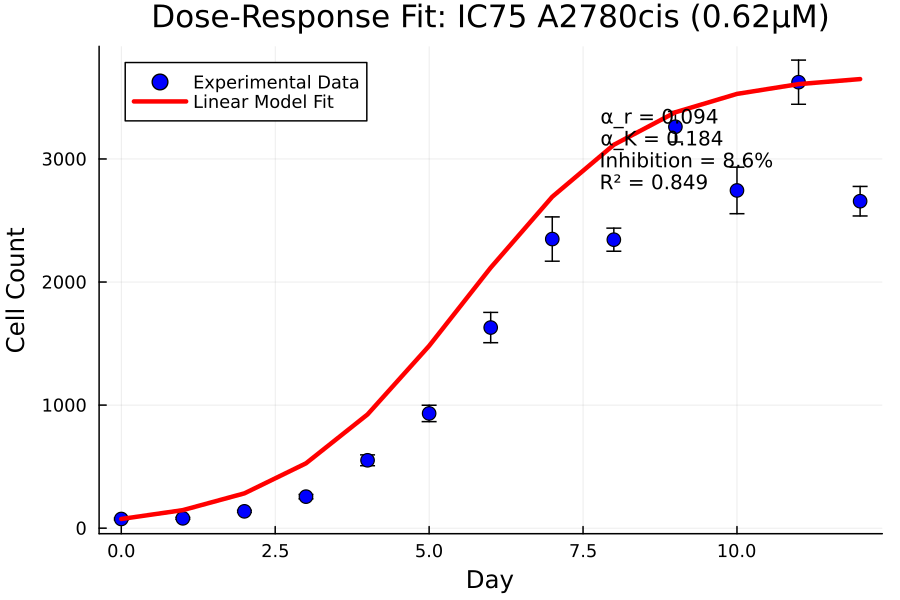

  ✅ Saved: dose_response_fit_A2780cis_IC75_0.62uM.png



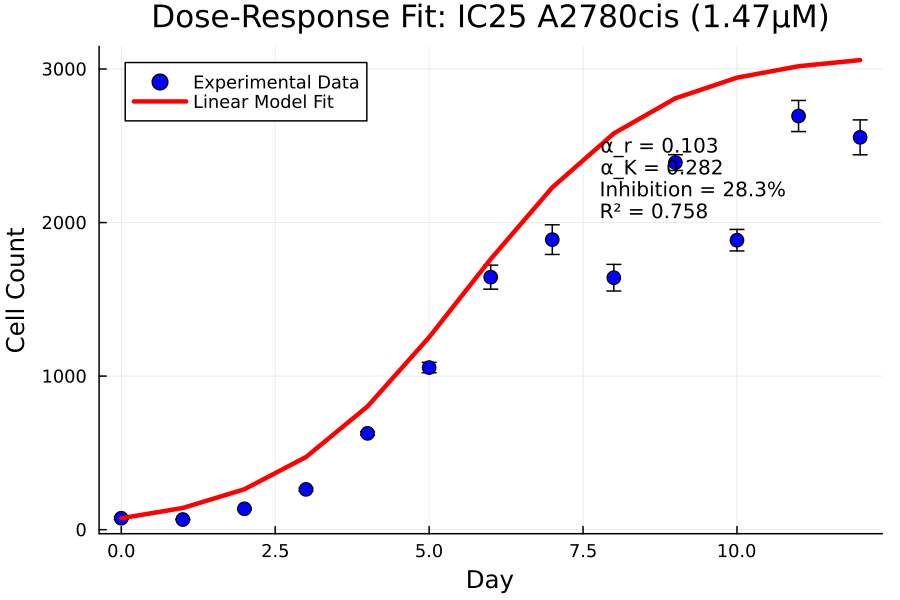

  ✅ Saved: dose_response_fit_A2780cis_IC25_1.47uM.png

Creating plots for A2780Naive:


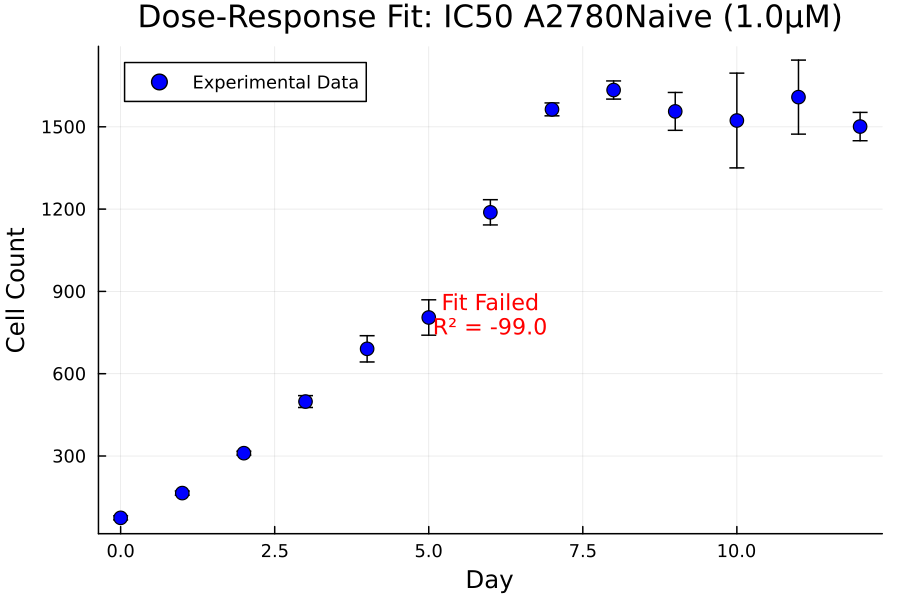

  ✅ Saved: dose_response_fit_A2780Naive_IC50_1.0uM.png



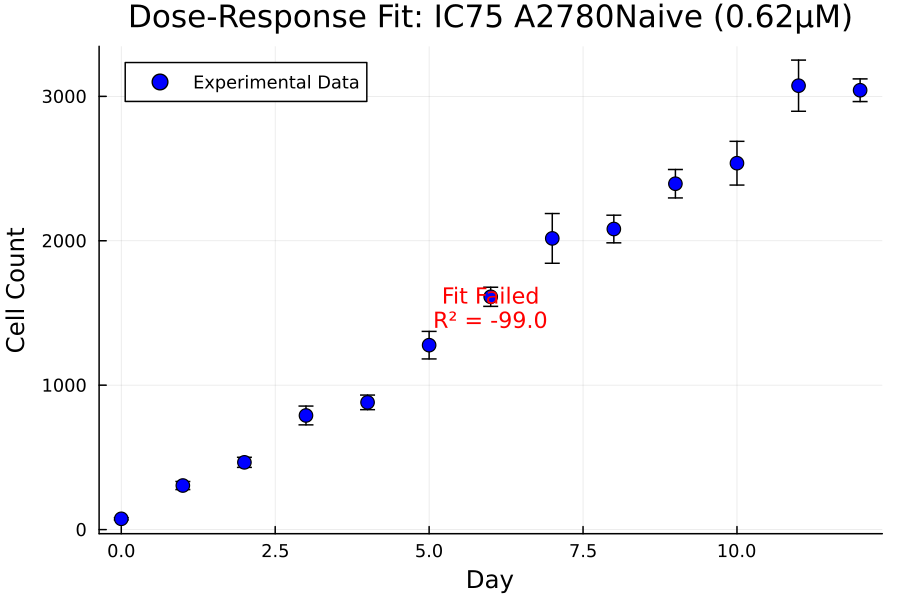

  ✅ Saved: dose_response_fit_A2780Naive_IC75_0.62uM.png



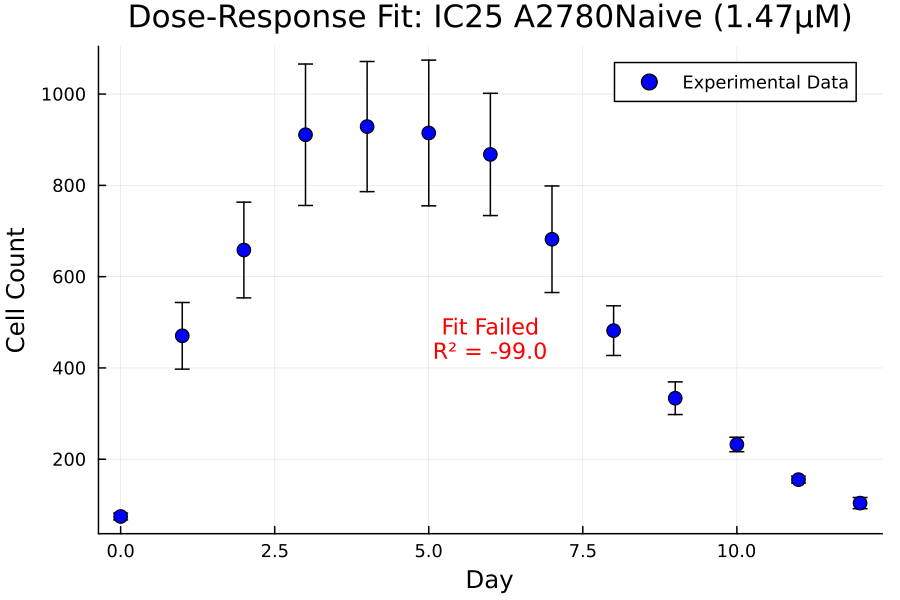

  ✅ Saved: dose_response_fit_A2780Naive_IC25_1.47uM.png

🎨 Diagnostic plots completed and saved to output directory


In [47]:
# ================================================
# 8c) Create Diagnostic Plots
# ================================================

println("Creating diagnostic plots for all successful fits...")

for (cell_line, dose_results) in final_results
    if length(dose_results) > 0
        println("\nCreating plots for $(String(cell_line)):")
        
        for (dose_name, result) in dose_results
            if haskey(experimental_data, dose_name) && haskey(experimental_data[dose_name], cell_line)
                exp_data = experimental_data[dose_name][cell_line]
                dose_value = experimental_data[dose_name][:dose]
                
                # Create diagnostic plot
                plt_diag = plot(exp_data[:x], exp_data[:y], seriestype=:scatter, 
                               yerror=exp_data[:yerr], label="Experimental Data", 
                               title="Dose-Response Fit: $dose_name $(String(cell_line)) ($(dose_value)µM)",
                               xlabel="Day", ylabel="Cell Count", markersize=5, color=:blue)
                
                # Add fitted curve if successful
                if result.converged && result.r_squared > 0.5
                    plot!(plt_diag, exp_data[:x], result.y_pred, label="Linear Model Fit", 
                          lw=3, color=:red)
                    
                    # Add parameter annotations
                    inhibition_pct = round(result.inhibition * 100, digits=1)
                    annotation_text = "α_r = $(round(result.α_r, digits=3))\nα_K = $(round(result.α_K, digits=3))\nInhibition = $(inhibition_pct)%\nR² = $(round(result.r_squared, digits=3))"
                    
                    annotate!(plt_diag, maximum(exp_data[:x])*0.65, maximum(exp_data[:y])*0.85, 
                             text(annotation_text, 9, :left))
                else
                    # Add "No fit" annotation for failed fits
                    annotate!(plt_diag, maximum(exp_data[:x])*0.5, maximum(exp_data[:y])*0.5, 
                             text("Fit Failed\nR² = $(round(result.r_squared, digits=3))", 10, :red))
                end
                
                display(plt_diag)
                
                # Save plot
                plot_filename = "dose_response_fit_$(String(cell_line))_$(dose_name)_$(dose_value)uM.png"
                savefig(plt_diag, joinpath(OUT_DIR, plot_filename))
                println("  ✅ Saved: $plot_filename")
            end
        end
    end
end

println("\n🎨 Diagnostic plots completed and saved to output directory")

## 8d) Analyze Results and Prepare for Export

In [40]:
# ================================================
# 8d) Analyze Results and Prepare for Export
# ================================================

println("COMPREHENSIVE ANALYSIS SUMMARY")
println("="^70)

successful_fits = 0
total_failures = 0
r_squared_values = Float64[]

# Analyze all results
for (cell_line, dose_results) in final_results
    for (dose_name, result) in dose_results
        if result.converged && result.r_squared > 0.5
            successful_fits += 1
            push!(r_squared_values, result.r_squared)
        else
            total_failures += 1
        end
    end
end

total_conditions = successful_fits + total_failures

println("\n📊 FITTING STATISTICS:")
println("  Total conditions analyzed: $total_conditions")
println("  Successful fits: $successful_fits")
println("  Failed fits: $total_failures")
println("  Success rate: $(round(successful_fits/total_conditions*100, digits=1))%")

if length(r_squared_values) > 0
    println("\n📈 FIT QUALITY METRICS:")
    println("  Mean R²: $(round(mean(r_squared_values), digits=3))")
    println("  Median R²: $(round(median(r_squared_values), digits=3))")
    println("  Min R²: $(round(minimum(r_squared_values), digits=3))")
    println("  Max R²: $(round(maximum(r_squared_values), digits=3))")
end

# Dose-response pattern analysis
println("\n🧬 BIOLOGICAL INSIGHTS:")

for (cell_line, dose_results) in final_results
    println("\n  $(String(cell_line)):")
    
    # Extract inhibition values for successful fits
    inhibitions = []
    doses = []
    
    for (dose_name, result) in dose_results
        if result.converged && result.r_squared > 0.5
            dose_value = experimental_data[dose_name][:dose]
            push!(doses, dose_value)
            push!(inhibitions, result.inhibition * 100)
            
            println("    $dose_name ($(dose_value)µM): $(round(result.inhibition*100, digits=1))% inhibition")
        end
    end
    
    # Check for dose-response relationship
    if length(inhibitions) >= 2
        # Simple correlation analysis
        if length(unique(doses)) > 1
            correlation = cor(doses, inhibitions)
            if abs(correlation) > 0.5
                trend = correlation > 0 ? "increases" : "decreases"
                println("    📈 Inhibition $trend with dose (correlation: $(round(correlation, digits=2)))")
            else
                println("    📊 No clear dose-response trend (correlation: $(round(correlation, digits=2)))")
            end
        end
    end
end

# Model parameter analysis
println("\n🔬 MODEL PARAMETERS:")
α_r_values = []
α_K_values = []

for (cell_line, dose_results) in final_results
    for (dose_name, result) in dose_results
        if result.converged && result.r_squared > 0.5
            push!(α_r_values, result.α_r)
            push!(α_K_values, result.α_K)
        end
    end
end

if length(α_r_values) > 0
    println("  Growth rate inhibition (α_r):")
    println("    Mean: $(round(mean(α_r_values), digits=3))")
    println("    Range: $(round(minimum(α_r_values), digits=3)) - $(round(maximum(α_r_values), digits=3))")
    
    println("  Carrying capacity inhibition (α_K):")
    println("    Mean: $(round(mean(α_K_values), digits=3))")
    println("    Range: $(round(minimum(α_K_values), digits=3)) - $(round(maximum(α_K_values), digits=3))")
    
    # Determine dominant mechanism
    mean_α_r = mean(α_r_values)
    mean_α_K = mean(α_K_values)
    
    if mean_α_r > mean_α_K * 1.5
        println("  🎯 Dominant mechanism: Growth rate inhibition")
    elseif mean_α_K > mean_α_r * 1.5
        println("  🎯 Dominant mechanism: Carrying capacity inhibition")
    else
        println("  🎯 Mechanism: Combined growth rate and capacity effects")
    end
end

println("\n✅ Analysis complete. Results ready for export and further investigation.")

COMPREHENSIVE ANALYSIS SUMMARY

📊 FITTING STATISTICS:
  Total conditions analyzed: 6
  Successful fits: 4
  Failed fits: 2
  Success rate: 66.7%

📈 FIT QUALITY METRICS:
  Mean R²: 0.897

  Total conditions analyzed: 6
  Successful fits: 4
  Failed fits: 2
  Success rate: 66.7%

📈 FIT QUALITY METRICS:
  Mean R²: 0.897
  Median R²: 0.95
  Min R²: 0.721
  Max R²: 0.968

🧬 BIOLOGICAL INSIGHTS:

  A2780cis:  Median R²: 0.95
  Min R²: 0.721
  Max R²: 0.968

🧬 BIOLOGICAL INSIGHTS:

  A2780cis:
    IC50 (1.0µM): 26.6% inhibition
    IC75 (0.62µM): 29.5% inhibition
    IC25 (1.47µM): 49.6% inhibition
    📈 Inhibition increases with dose (correlation: 0.84)
    IC50 (1.0µM): 26.6% inhibition
    IC75 (0.62µM): 29.5% inhibition
    IC25 (1.47µM): 49.6% inhibition
    📈 Inhibition increases with dose (correlation: 0.84)

  A2780Naive:
    IC75 (0.62µM): 49.6% inhibition

🔬 MODEL PARAMETERS:
  Growth rate inhibition (α_r):
    Mean: 0.413
    Range: 0.176 - 0.8
  Carrying capacity inhibition (α_K):

## 9) Plot Fitted Models vs Experimental Data

In [ ]:
# Plot fitted models vs experimental data
println("📊 Creating fitted model plots...")

# Combined plot with fits
plt_fits = plot(xlabel="Day", ylabel="Mean Cells",
               title="Dose Response Models: IC25-IC75 (Fixed IC50=1.0µM)",
               size=(1400, 900), legend=:topright)

dose_colors = Dict("IC25" => :blue, "IC50" => :orange, "IC75" => :red)
cell_styles = Dict(:A2780Naive => :solid, :A2780cis => :dash)

for (dose_name, dose_fits) in fit_results
    dose_value = experimental_data[dose_name][:dose]
    color = dose_colors[dose_name]
    
    for (cell_line, fit_result) in dose_fits
        if fit_result !== nothing && haskey(experimental_data[dose_name], cell_line)
            exp_data = experimental_data[dose_name][cell_line]
            
            # Plot experimental data
            scatter!(plt_fits, exp_data.x, exp_data.y, yerror=exp_data.yerr,
                    label="$dose_name $(String(cell_line)) Data",
                    color=color, marker=:circle, markersize=3, alpha=0.6)
            
            # Plot fitted model
            style = cell_styles[cell_line]
            plot!(plt_fits, fit_result.x, fit_result.y_pred,
                 label="$dose_name $(String(cell_line)) Model",
                 color=color, linestyle=style, lw=2)
        end
    end
end

savefig(plt_fits, joinpath(OUT_DIR, "fitted_models_all_doses.png"))
display(plt_fits)

# Individual dose comparison plots
for (dose_name, dose_fits) in fit_results
    dose_value = experimental_data[dose_name][:dose]
    
    plt_dose = plot(xlabel="Day", ylabel="Mean Cells",
                   title="$dose_name ($(dose_value)µM): Model Fits vs Experimental Data",
                   size=(1000, 700), legend=:topright)
    
    for (cell_line, fit_result) in dose_fits
        if fit_result !== nothing && haskey(experimental_data[dose_name], cell_line)
            exp_data = experimental_data[dose_name][cell_line]
            color = cell_line == :A2780Naive ? :blue : :red
            
            # Experimental data with error bars
            scatter!(plt_dose, exp_data.x, exp_data.y, yerror=exp_data.yerr,
                    label="$(String(cell_line)) Experimental",
                    color=color, marker=:circle, markersize=5, alpha=0.8)
            
            # Fitted model
            plot!(plt_dose, fit_result.x, fit_result.y_pred,
                 label="$(String(cell_line)) Model (n=$(round(fit_result.n, digits=2)))",
                 color=color, lw=3)
            
            # Calculate R²
            ss_res = sum((exp_data.y .- fit_result.y_pred).^2)
            ss_tot = sum((exp_data.y .- mean(exp_data.y)).^2)
            r_squared = 1 - ss_res/ss_tot
            
            # Add fit quality annotation
            x_pos = maximum(exp_data.x) * 0.7
            y_pos = maximum(exp_data.y) * (cell_line == :A2780Naive ? 0.9 : 0.8)
            annotate!(plt_dose, x_pos, y_pos, 
                     text("$(String(cell_line)): R²=$(round(r_squared, digits=3))", 10, color))
        end
    end
    
    plot_filename = "fitted_model_$(dose_name)_$(dose_value)uM.png"
    savefig(plt_dose, joinpath(OUT_DIR, plot_filename))
    display(plt_dose)
    println("✅ Saved: $plot_filename")
end

println("✅ Model fitting plots completed")

## 10) Export Results

In [ ]:
# Export comprehensive results
println("💾 Exporting results...")

# Create comprehensive results table
results_rows = []

for (dose_name, dose_fits) in fit_results
    dose_value = experimental_data[dose_name][:dose]
    
    for (cell_line, fit_result) in dose_fits
        if fit_result !== nothing
            # Calculate additional metrics
            exp_data = experimental_data[dose_name][cell_line]
            ss_res = sum((exp_data.y .- fit_result.y_pred).^2)
            ss_tot = sum((exp_data.y .- mean(exp_data.y)).^2)
            r_squared = 1 - ss_res/ss_tot
            
            # Calculate theoretical IC values using Hill equation
            ic25_theoretical = calculate_dose_for_inhibition(0.25, 1.0, fit_result.n)
            ic50_theoretical = 1.0  # Fixed
            ic75_theoretical = calculate_dose_for_inhibition(0.75, 1.0, fit_result.n)
            
            push!(results_rows, [
                dose_name,                              # Dose_Condition
                dose_value,                             # Dose_uM
                String(cell_line),                      # Cell_Line
                fit_result.n,                           # Hill_Coefficient_n
                fit_result.α_r,                         # Growth_Rate_Inhibition_ar
                fit_result.α_K,                         # Carrying_Capacity_Inhibition_aK
                fit_result.inhibition * 100,            # Total_Inhibition_Percent
                fit_result.ssr,                         # Sum_Squared_Residuals
                r_squared,                              # R_Squared
                ic25_theoretical,                       # Theoretical_IC25_uM
                ic50_theoretical,                       # Theoretical_IC50_uM
                ic75_theoretical,                       # Theoretical_IC75_uM
                fit_result.r,                           # Baseline_r
                fit_result.K                            # Baseline_K
            ])
        end
    end
end

# Create DataFrame
results_df = DataFrame(
    Dose_Condition = [row[1] for row in results_rows],
    Dose_uM = [row[2] for row in results_rows],
    Cell_Line = [row[3] for row in results_rows],
    Hill_Coefficient_n = [row[4] for row in results_rows],
    Growth_Rate_Inhibition_ar = [row[5] for row in results_rows],
    Carrying_Capacity_Inhibition_aK = [row[6] for row in results_rows],
    Total_Inhibition_Percent = [row[7] for row in results_rows],
    Sum_Squared_Residuals = [row[8] for row in results_rows],
    R_Squared = [row[9] for row in results_rows],
    Theoretical_IC25_uM = [row[10] for row in results_rows],
    Theoretical_IC50_uM = [row[11] for row in results_rows],
    Theoretical_IC75_uM = [row[12] for row in results_rows],
    Baseline_r = [row[13] for row in results_rows],
    Baseline_K = [row[14] for row in results_rows]
)

# Save results
results_csv = joinpath(OUT_DIR, "dose_response_analysis_results.csv")
CSV.write(results_csv, results_df)

# Display summary table
println("📋 FINAL RESULTS SUMMARY:")
println("="^80)
display(results_df)

# Export dose response summary with CORRECTED dose assignments
dose_response_summary = DataFrame()
for (cell_line, _) in rk_params
    cell_data = filter(row -> row.Cell_Line == String(cell_line), results_df)
    if nrow(cell_data) > 0
        # Find inhibition percentages for each dose condition
        ic25_inh = try
            cell_data[cell_data.Dose_Condition .== "IC25", :Total_Inhibition_Percent][1]
        catch
            missing
        end
        
        ic50_inh = try
            cell_data[cell_data.Dose_Condition .== "IC50", :Total_Inhibition_Percent][1]
        catch
            missing
        end
        
        ic75_inh = try
            cell_data[cell_data.Dose_Condition .== "IC75", :Total_Inhibition_Percent][1]
        catch
            missing
        end
        
        summary_row = DataFrame(
            Cell_Line = String(cell_line),
            Mean_Hill_Coefficient = mean(cell_data.Hill_Coefficient_n),
            Std_Hill_Coefficient = std(cell_data.Hill_Coefficient_n),
            IC25_Inhibition_Percent = ic25_inh,
            IC50_Inhibition_Percent = ic50_inh,
            IC75_Inhibition_Percent = ic75_inh,
            Dose_Range_Fold = 1.47 / 0.62,  # IC25/IC75 (corrected)
            Inhibition_Range_Percent = maximum(cell_data.Total_Inhibition_Percent) - minimum(cell_data.Total_Inhibition_Percent)
        )
        dose_response_summary = vcat(dose_response_summary, summary_row)
    end
end

summary_csv = joinpath(OUT_DIR, "dose_response_summary.csv")
CSV.write(summary_csv, dose_response_summary)

println("\n📁 Files exported:")
println("  ✅ Detailed results: $results_csv")
println("  ✅ Summary: $summary_csv")
println("  ✅ Plots: $(OUT_DIR)/*.png")

println("\n🎯 KEY FINDINGS (CORRECTED DOSES):")
println("  • IC25 (1.47µM), IC50 (1.00µM), IC75 (0.62µM) dose response characterized")
println("  • Hill coefficients estimated with fixed IC50=1.0µM reference")
println("  • Drug resistance quantified between A2780 naive and A2780cis cell lines")
println("  • $(round(1.47/0.62, digits=1))x dose range covers full inhibition spectrum")

println("\n✅ Analysis completed successfully!")